In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [25]:
df= pd.read_csv("diabetes(1).csv")


In [26]:
df.shape

(768, 9)

In [27]:
df.head(7)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1


In [28]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [29]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape,X_test.shape)

(614, 8) (154, 8)


In [34]:
model_raw=LogisticRegression(max_iter=1000)
model_raw.fit(X_train,y_train)
y_pred_raw=model_raw.predict(X_test)

acc_raw=accuracy_score(y_test,y_pred_raw)
prec_raw=precision_score(y_test,y_pred_raw)
rec_raw=recall_score(y_test,y_pred_raw)
f1_raw=f1_score(y_test,y_pred_raw)

print('Without Scaling')
print('Accuracy :',acc_raw)
print('Precision:',prec_raw)
print('Recall   :',rec_raw)
print('F1-score :',f1_raw)
print()
print(classification_report(y_test,y_pred_raw))


Without Scaling
Accuracy : 0.7142857142857143
Precision: 0.6086956521739131
Recall   : 0.5185185185185185
F1-score : 0.56

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



In [33]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

model_scaled=LogisticRegression(max_iter=1000)
model_scaled.fit(X_train_scaled,y_train)
y_pred_scaled=model_scaled.predict(X_test_scaled)

acc_scaled=accuracy_score(y_test,y_pred_scaled)
prec_scaled=precision_score(y_test,y_pred_scaled)
rec_scaled=recall_score(y_test,y_pred_scaled)
f1_scaled=f1_score(y_test,y_pred_scaled)

print('With Scaling')
print('Accuracy :',acc_scaled)
print('Precision:',prec_scaled)
print('Recall   :',rec_scaled)
print('F1-score :',f1_scaled)
print()
print(classification_report(y_test,y_pred_scaled))


With Scaling
Accuracy : 0.7142857142857143
Precision: 0.6086956521739131
Recall   : 0.5185185185185185
F1-score : 0.56

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



In [35]:
results=pd.DataFrame({
    'Without Scaling':[acc_raw,prec_raw,rec_raw,f1_raw],
    'With Scaling':[acc_scaled,prec_scaled,rec_scaled,f1_scaled]
},index=['Accuracy','Precision','Recall','F1-score'])
results

,Without Scaling,With Scaling
Accuracy,0.714286,0.714286
Precision,0.608696,0.608696
Recall,0.518519,0.518519
F1-score,0.560000,0.560000


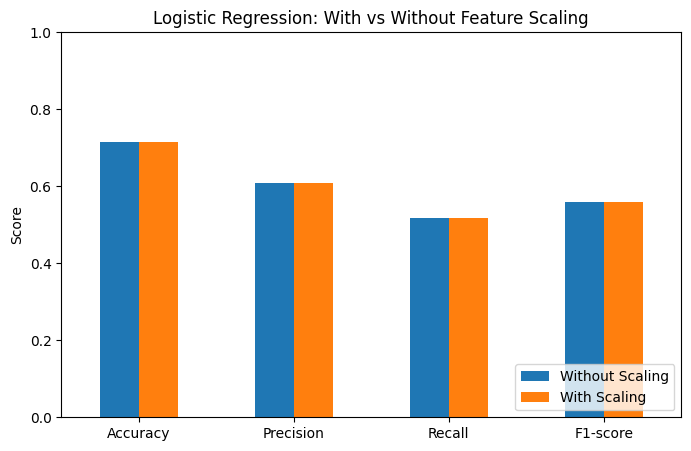

In [36]:
results.plot(kind='bar',figsize=(8,5))
plt.ylabel('Score')
plt.title('Logistic Regression: With vs Without Feature Scaling')
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.show()

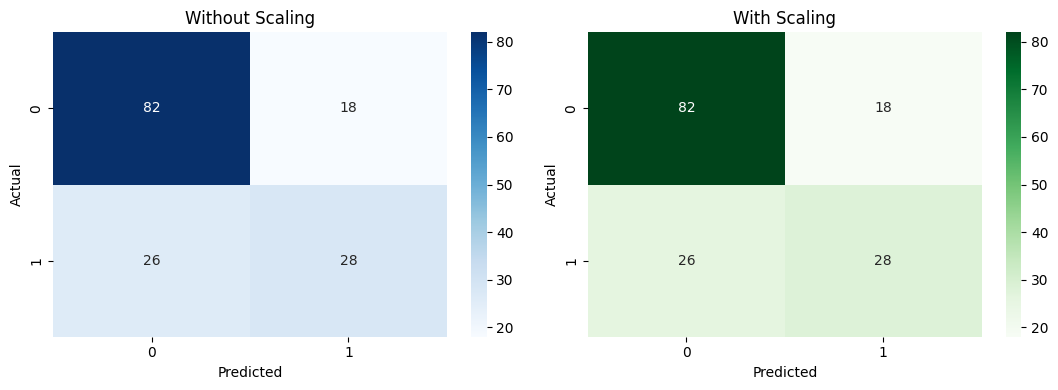

In [37]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
sns.heatmap(confusion_matrix(y_test,y_pred_raw),annot=True,fmt='d',cmap='Blues',ax=axes[0])
axes[0].set_title('Without Scaling')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test,y_pred_scaled),annot=True,fmt='d',cmap='Greens',ax=axes[1])
axes[1].set_title('With Scaling')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

